# AI Product Intelligence System

**Tasks Covered:**
- **Task 1:** Smart Product Recommendation Engine
- **Task 2:** Unique Product Catalog Creation
- **Task 3:** Reverse Product Search (Text-to-Product)

**Dataset:** [Fashion Product Images Small](https://www.kaggle.com/code/sahandakramipour/fashion-product-images-small)

## 📦 Step 1: Install & Import Dependencies

In [46]:
import sys
print(sys.executable)  # This will show which Python Jupyter is using

c:\Users\RAGUL N\AppData\Local\Programs\Python\Python311\python.exe


In [47]:
import sys
!"{sys.executable}" -m pip install faiss-cpu


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Install required libraries
!pip install transformers torch torchvision Pillow scikit-learn matplotlib seaborn pandas numpy faiss-cpu tqdm -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [49]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
import faiss

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

✅ All libraries imported successfully!
PyTorch version: 2.9.1+cpu
Device: cpu


## 📂 Step 2: Load Dataset

In [50]:
# ─── Kaggle path setup ────────────────────────────────────────────
# On Kaggle the dataset is typically at /kaggle/input/
# Adjust the path below if yours differs.

DATASET_BASE = Path(r"C:\Users\RAGUL N\Downloads\archive (4)")
IMAGES_DIR   = DATASET_BASE / 'images'
CSV_PATH     = DATASET_BASE / 'styles.csv'

# Fallback: current directory
if not DATASET_BASE.exists():
    DATASET_BASE = Path('.')
    IMAGES_DIR   = DATASET_BASE / 'images'
    CSV_PATH     = DATASET_BASE / 'styles.csv'

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
print(f"Dataset shape: {df.shape}")
print(df.head())
print("\nColumns:", df.columns.tolist())

Dataset shape: (44424, 10)
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'ye

In [51]:
# Keep only rows whose image file actually exists and sample for speed
df['image_path'] = df['id'].apply(lambda x: str(IMAGES_DIR / f"{x}.jpg"))
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

# Sample 10,000 products for faster experimentation (increase if you have GPU)
SAMPLE_SIZE = 10000
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

print(f"Working with {len(df)} products")
print(df[['id','productDisplayName','masterCategory','subCategory','articleType']].head(10))

Working with 10000 products
      id                               productDisplayName masterCategory  \
0  16947     Image Women Classic Eyewear Brown Sunglasses    Accessories   
1  40524                Titan Men White Chronograph Watch    Accessories   
2  36313               Mr.Men Boys Blazing Yellow T-shirt        Apparel   
3  44188                   iPanema Women Black Flip Flops       Footwear   
4  33859                 Puma Women Lucie Pink Flip Flops       Footwear   
5  39306                 Red Chief Men Black Casual Shoes       Footwear   
6  37097  Wills Lifestyle Men Multi Coloured Polo T-shirt        Apparel   
7  29705               John Miller Men Striped Blue Shirt        Apparel   
8  56314                    Fastrack Women Red Dial Watch    Accessories   
9  13541       Carlton London Women Casual Purple Sandals       Footwear   

  subCategory   articleType  
0     Eyewear    Sunglasses  
1     Watches       Watches  
2     Topwear       Tshirts  
3  Flip Flops  

## 🤖 Step 3: Load CLIP Model & Generate Embeddings

CLIP (Contrastive Language-Image Pre-training) maps **images** and **text** into the **same embedding space**, enabling cross-modal similarity search.

In [52]:
print("Loading CLIP model...")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("✅ CLIP model loaded!")

Loading CLIP model...
✅ CLIP model loaded!


In [53]:
def get_image_embedding(image_path: str) -> np.ndarray:
    """Return a normalised CLIP image embedding for one image."""
    image = Image.open(image_path).convert('RGB')
    inputs = clip_processor(images=image, return_tensors='pt').to(device)
    with torch.no_grad():
        features = clip_model.get_image_features(**inputs)
    features = features / features.norm(dim=-1, keepdim=True)   # L2-normalise
    return features.cpu().numpy().flatten()


def get_text_embedding(text: str) -> np.ndarray:
    """Return a normalised CLIP text embedding."""
    inputs = clip_processor(text=[text], return_tensors='pt', padding=True,
                            truncation=True, max_length=77).to(device)
    with torch.no_grad():
        features = clip_model.get_text_features(**inputs)
    features = features / features.norm(dim=-1, keepdim=True)
    return features.cpu().numpy().flatten()


# ─── Generate image embeddings for the whole sample ───────────────
print("Generating image embeddings (this may take a few minutes)…")
embeddings = []
valid_indices = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        emb = get_image_embedding(row['image_path'])
        embeddings.append(emb)
        valid_indices.append(i)
    except Exception as e:
        pass   # skip corrupt images

embeddings = np.array(embeddings, dtype=np.float32)
df_valid   = df.loc[valid_indices].reset_index(drop=True)

print(f"\n✅ Embeddings shape: {embeddings.shape}")
print(f"Valid products: {len(df_valid)}")

Generating image embeddings (this may take a few minutes)…


100%|██████████| 10000/10000 [10:18<00:00, 16.17it/s]


✅ Embeddings shape: (10000, 512)
Valid products: 10000


In [54]:
# Build a FAISS index for fast nearest-neighbour search
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # Inner-Product == cosine sim for L2-normed vecs
index.add(embeddings)
print(f"FAISS index built with {index.ntotal} vectors (dim={dim})")

FAISS index built with 10000 vectors (dim=512)


---
## 🛒 Task 1: Smart Product Recommendation Engine

**Approach:** 
1. Embed the query product image with CLIP  
2. Retrieve *visually similar* products via FAISS  
3. Use category-based **complementary rules** (e.g., shoes → socks, belt) to suggest items often bought together  
4. Optionally re-rank with a rule-based co-purchase score

In [55]:
# ─── Category-level complementary rules ───────────────────────────
COMPLEMENTARY_RULES = {
    'Shoes':       ['Socks', 'Belts', 'Trousers', 'Casual Shoes'],
    'Tshirts':     ['Jeans', 'Track Pants', 'Shorts', 'Jackets'],
    'Shirts':      ['Jeans', 'Trousers', 'Belts', 'Formal Shoes'],
    'Jeans':       ['Tshirts', 'Shirts', 'Casual Shoes', 'Belts'],
    'Dresses':     ['Heels', 'Flats', 'Handbags', 'Earrings'],
    'Watches':     ['Shirts', 'Formal Shoes', 'Wallets'],
    'Handbags':    ['Dresses', 'Flats', 'Sunglasses'],
    'Sunglasses':  ['Caps', 'Tshirts', 'Shorts'],
    'Jackets':     ['Jeans', 'Boots', 'Tshirts'],
    'Formal Shoes':['Shirts', 'Trousers', 'Belts', 'Ties'],
    'Trousers':    ['Shirts', 'Formal Shoes', 'Belts'],
    'Shorts':      ['Tshirts', 'Casual Shoes', 'Sunglasses'],
}

def get_complementary_categories(article_type: str) -> list:
    """Return complementary product types based on rules."""
    for key, comps in COMPLEMENTARY_RULES.items():
        if key.lower() in article_type.lower():
            return comps
    return ['Tshirts', 'Jeans', 'Casual Shoes']   # generic default


def recommend_complementary(product_idx: int,
                             top_k_similar: int = 20,
                             top_k_result: int  = 5) -> pd.DataFrame:
    """
    Given the index of a product in df_valid:
      1. Find top_k_similar visually similar products with FAISS.
      2. Filter by complementary category rules.
      3. Return top_k_result recommendations.
    """
    query_emb   = embeddings[product_idx:product_idx+1]
    query_row   = df_valid.iloc[product_idx]
    comp_cats   = get_complementary_categories(query_row['articleType'])

    # FAISS search over whole catalog
    scores, idxs = index.search(query_emb, top_k_similar + 1)
    idxs  = idxs[0][1:]   # exclude the product itself
    scores = scores[0][1:]

    candidates = df_valid.iloc[idxs].copy()
    candidates['similarity_score'] = scores

    # Keep items whose articleType matches complementary categories
    mask = candidates['articleType'].apply(
        lambda t: any(c.lower() in t.lower() for c in comp_cats)
    )
    filtered = candidates[mask]

    # Fall back to visually similar if too few complementary items
    if len(filtered) < top_k_result:
        filtered = candidates

    return filtered.head(top_k_result)[['id', 'productDisplayName',
                                        'articleType', 'baseColour',
                                        'similarity_score', 'image_path']]


# ─── Demo ─────────────────────────────────────────────────────────
QUERY_IDX = 0
query_product = df_valid.iloc[QUERY_IDX]
print("🔍 Query Product:")
print(f"  Name : {query_product['productDisplayName']}")
print(f"  Type : {query_product['articleType']}")
print(f"  Colour: {query_product['baseColour']}")

recs = recommend_complementary(QUERY_IDX)
print("\n🛒 Recommended Complementary Products:")
print(recs[['productDisplayName', 'articleType', 'baseColour', 'similarity_score']].to_string(index=False))

🔍 Query Product:
  Name : Image Women Classic Eyewear Brown Sunglasses
  Type : Sunglasses
  Colour: Brown

🛒 Recommended Complementary Products:
                             productDisplayName articleType baseColour  similarity_score
                      Polaroid Women Sunglasses  Sunglasses      Brown          0.980576
 Mayhem Women Gradiant Sunglasses MAYS-9007-201  Sunglasses      Brown          0.979063
                   Miami Blues Women Sunglasses  Sunglasses      Brown          0.977445
       M tv Men My Fab Eyewear Brown Sunglasses  Sunglasses      Brown          0.977369
Allen Solly Women Oversized Sunglasses AH220-C2  Sunglasses      Brown          0.976930


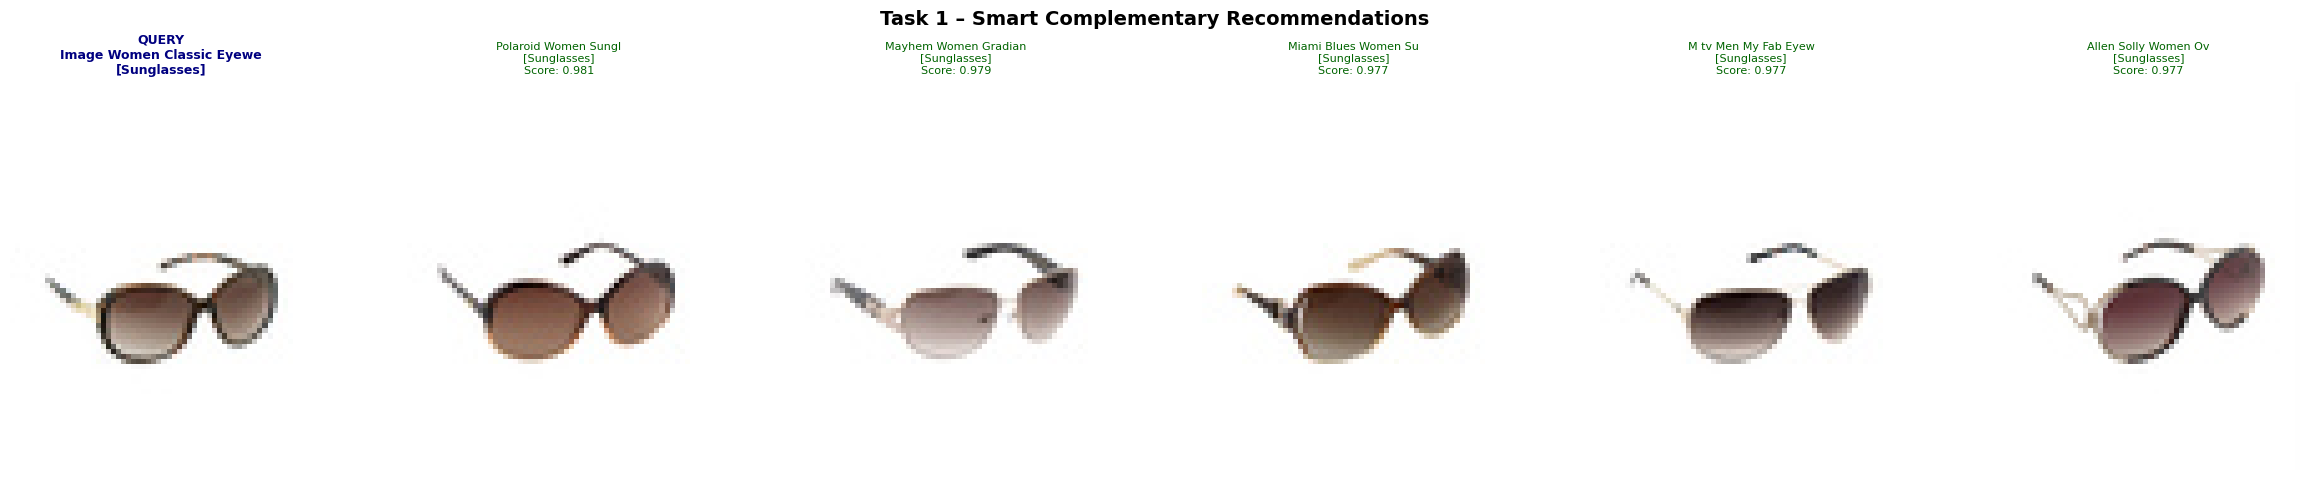

💾 Saved: task1_recommendations.png


In [56]:
# ─── Visualisation ────────────────────────────────────────────────
def visualize_recommendations(query_idx: int, recs: pd.DataFrame):
    query_row = df_valid.iloc[query_idx]
    n_recs    = len(recs)

    fig, axes = plt.subplots(1, n_recs + 1, figsize=(4 * (n_recs + 1), 5))
    fig.suptitle('Task 1 – Smart Complementary Recommendations', fontsize=14, fontweight='bold')

    # Query image
    query_img = Image.open(query_row['image_path']).convert('RGB')
    axes[0].imshow(query_img)
    axes[0].set_title(f"QUERY\n{query_row['productDisplayName'][:25]}\n[{query_row['articleType']}]",
                      fontsize=9, color='navy', fontweight='bold')
    axes[0].axis('off')
    axes[0].patch.set_edgecolor('navy')
    axes[0].patch.set_linewidth(3)

    for ax, (_, rec) in zip(axes[1:], recs.iterrows()):
        try:
            img = Image.open(rec['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        ax.set_title(f"{rec['productDisplayName'][:20]}\n[{rec['articleType']}]\nScore: {rec['similarity_score']:.3f}",
                     fontsize=8, color='darkgreen')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('task1_recommendations.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("💾 Saved: task1_recommendations.png")


visualize_recommendations(QUERY_IDX, recs)

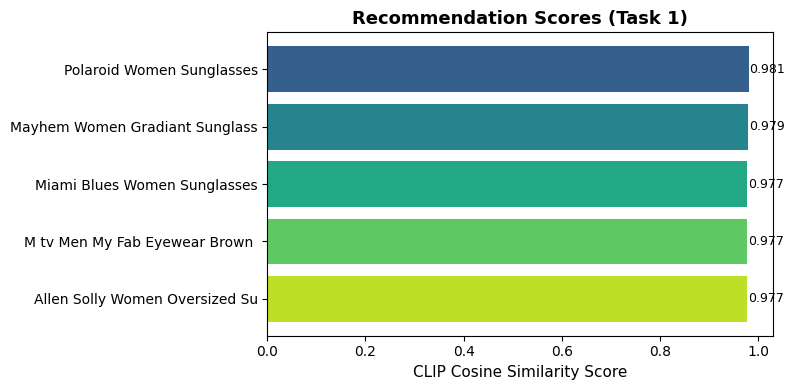

In [57]:
# ─── Bar chart of recommendation scores ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors  = plt.cm.viridis(np.linspace(0.3, 0.9, len(recs)))

bars = ax.barh(recs['productDisplayName'].str[:30], recs['similarity_score'], color=colors)
ax.set_xlabel('CLIP Cosine Similarity Score', fontsize=11)
ax.set_title('Recommendation Scores (Task 1)', fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, score in zip(bars, recs['similarity_score']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('task1_scores.png', dpi=120, bbox_inches='tight')
plt.show()

### 📋 Task 1 Explanation

| Step | What happens |
|------|-------------|
| **1. CLIP Embedding** | Both query image and catalog images are embedded into a shared 512-d vector space. |
| **2. FAISS Search** | Inner-product (≡ cosine similarity for L2-normed vecs) retrieves top-20 nearest products. |
| **3. Complementary Rules** | A hand-crafted rule table maps each article type to its complementary categories (shoes→socks, shirts→trousers, …). |
| **4. Filter & Rank** | Only products matching complementary categories are retained; they are ranked by their CLIP similarity score. |

This mimics *"Frequently Bought Together"* logic used by Amazon/Flipkart, but with zero transaction data – purely from semantic understanding.

---
## 📑 Task 2: Unique Product Catalog Creation

**Approach:**
1. Cluster product embeddings with **Agglomerative Clustering** using a cosine distance threshold  
2. Within each cluster, select the representative product (closest to centroid)  
3. Output = 1 canonical product per cluster → clean, deduplicated catalog

In [58]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize

# L2-normalise (already done, but ensure)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
emb_normed = embeddings / (norms + 1e-9)

# Cosine distance = 1 – cosine_similarity
# distance_threshold: products with distance < threshold are "duplicates"
DISTANCE_THRESHOLD = 0.15   # tune between 0.10 (strict) and 0.30 (loose)

clustering = AgglomerativeClustering(
    n_clusters=None,
    metric='cosine',
    linkage='average',
    distance_threshold=DISTANCE_THRESHOLD
)

labels = clustering.fit_predict(emb_normed)
n_clusters = len(set(labels))

print(f"Total products      : {len(df_valid)}")
print(f"Unique clusters     : {n_clusters}")
print(f"Duplicates removed  : {len(df_valid) - n_clusters} ({(len(df_valid)-n_clusters)/len(df_valid)*100:.1f}%)")

df_valid['cluster_id'] = labels

Total products      : 10000
Unique clusters     : 597
Duplicates removed  : 9403 (94.0%)


In [59]:
# ─── Pick the representative product per cluster ──────────────────
def get_cluster_representative(cluster_label: int) -> pd.Series:
    """Return the product closest to the cluster centroid."""
    members_idx = np.where(labels == cluster_label)[0]
    cluster_embs = emb_normed[members_idx]
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    centroid /= np.linalg.norm(centroid)
    sims = (cluster_embs @ centroid.T).flatten()
    best = members_idx[sims.argmax()]
    return df_valid.iloc[best]


unique_catalog = []
for label in tqdm(sorted(set(labels)), desc='Building catalog'):
    rep = get_cluster_representative(label)
    cluster_size = int((labels == label).sum())
    row = rep.to_dict()
    row['cluster_size'] = cluster_size
    row['cluster_id']   = label
    unique_catalog.append(row)

catalog_df = pd.DataFrame(unique_catalog)
print(f"\n✅ Unique Catalog has {len(catalog_df)} products")
print(catalog_df[['productDisplayName','articleType','baseColour','cluster_size']].head(15).to_string(index=False))

Building catalog: 100%|██████████| 597/597 [00:00<00:00, 8201.26it/s]


✅ Unique Catalog has 597 products
                              productDisplayName           articleType baseColour  cluster_size
                  Lucera Gold Plated Paheli Ring                  Ring       Gold            34
              Myntra Men's Octopus White T-shirt               Tshirts      White            11
          Lino Perros Men Black & Red Suspenders            Suspenders      Black            11
         ADIDAS Unisex Black Strap Black Watches               Watches      Black            28
           Mark Taylor Men White Printed T-shirt               Tshirts      White             3
            Gini and Jony Boys Check Black Shirt                Shirts      Black            43
            ADIDAS Men Ranger White Sports Shoes          Sports Shoes      White           387
                        Scullers Men Grey Shorts                Shorts       Grey            62
         Nike Men White Ronaldo Football T-shirt               Tshirts      White             5
    U

Clusters with duplicates: 329


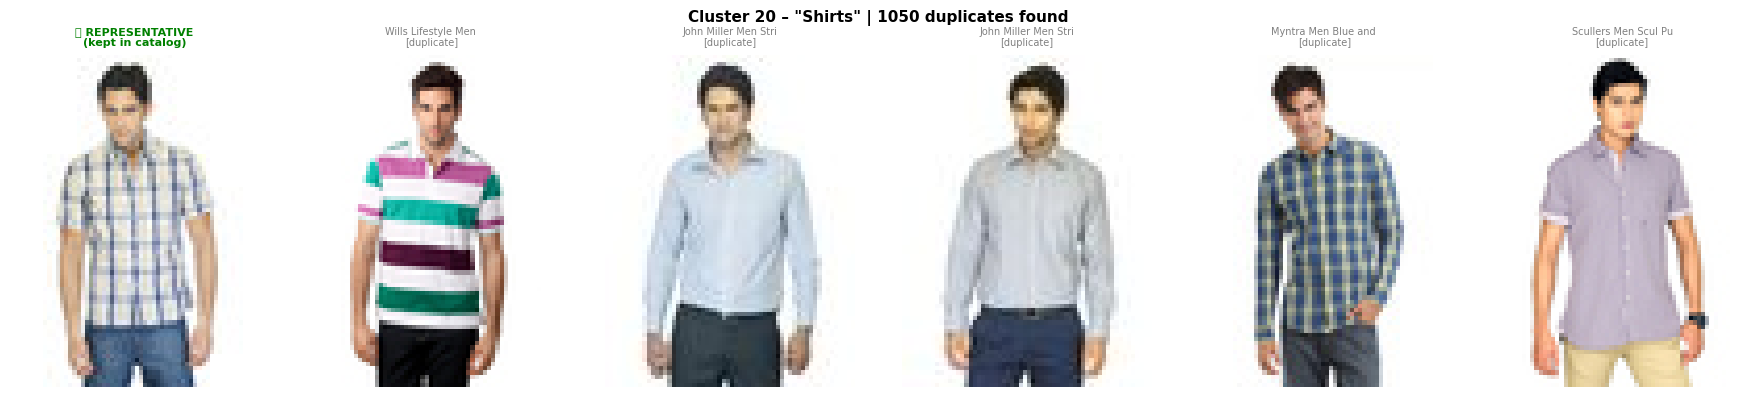

💾 Saved: task2_cluster_20.png


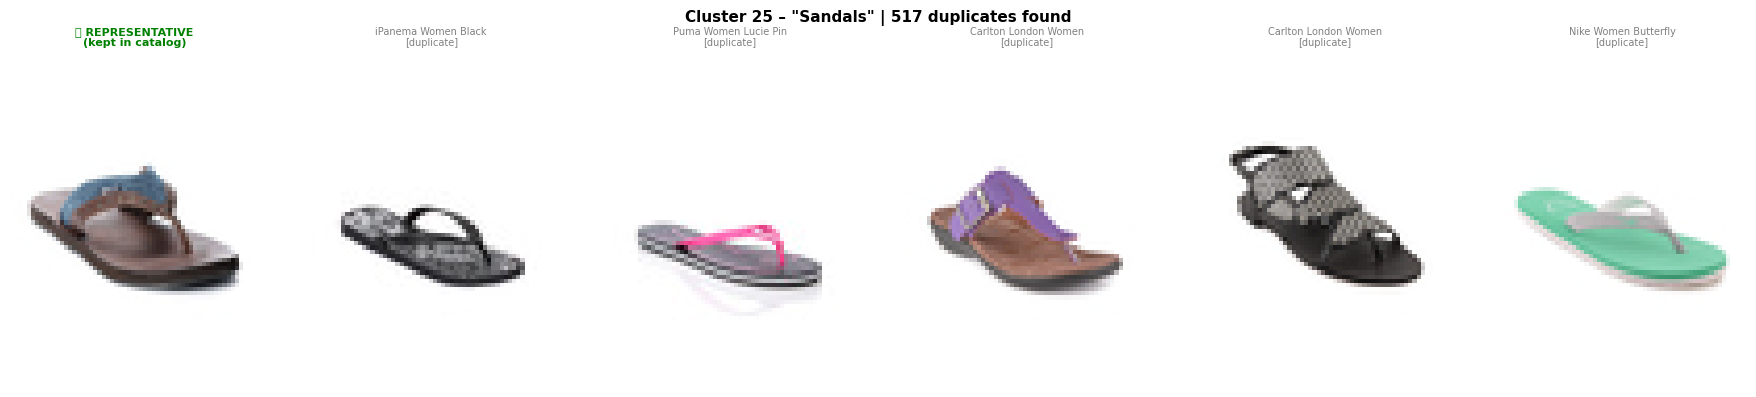

💾 Saved: task2_cluster_25.png


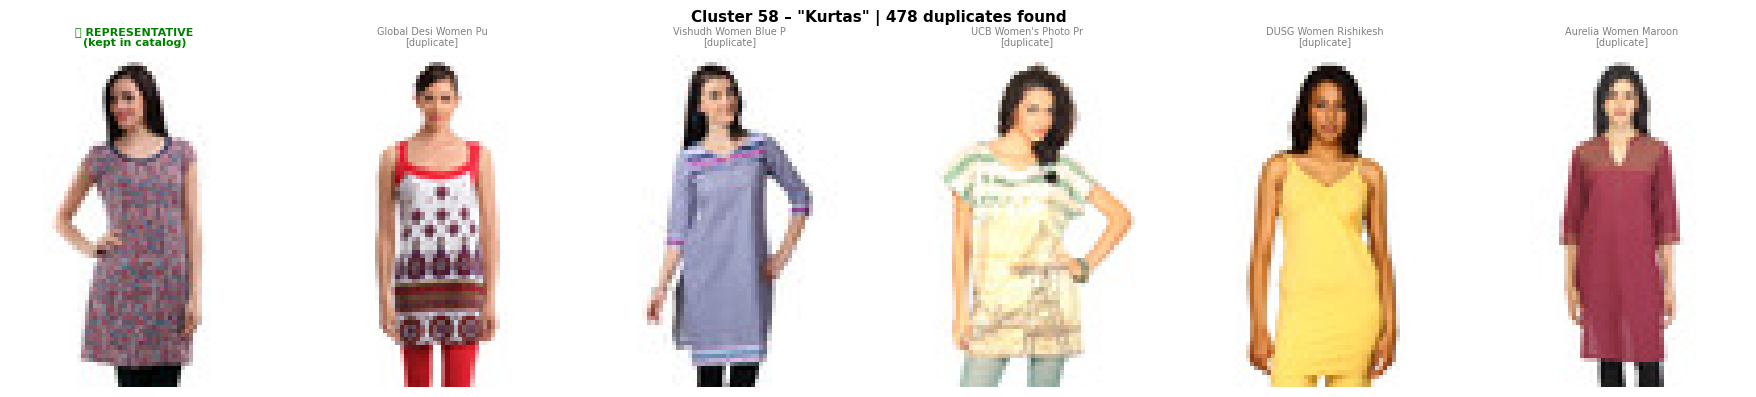

💾 Saved: task2_cluster_58.png


In [60]:
# ─── Visualise clustered duplicates ───────────────────────────────
# Show a few example clusters that have >1 member
dup_clusters = catalog_df[catalog_df['cluster_size'] > 1].sort_values('cluster_size', ascending=False)
print(f"Clusters with duplicates: {len(dup_clusters)}")

SHOW_CLUSTERS = min(3, len(dup_clusters))

for _, cluster_rep in dup_clusters.head(SHOW_CLUSTERS).iterrows():
    cid      = int(cluster_rep['cluster_id'])
    members  = df_valid[df_valid['cluster_id'] == cid]
    n_show   = min(5, len(members))

    fig, axes = plt.subplots(1, n_show + 1, figsize=(3 * (n_show + 1), 4))
    fig.suptitle(f'Cluster {cid} – "{cluster_rep["articleType"]}" | {len(members)} duplicates found',
                 fontsize=11, fontweight='bold')

    # Representative
    try:
        axes[0].imshow(Image.open(cluster_rep['image_path']).convert('RGB'))
    except:
        axes[0].text(0.5, 0.5, 'No Image', ha='center', va='center')
    axes[0].set_title('✅ REPRESENTATIVE\n(kept in catalog)', fontsize=8, color='green', fontweight='bold')
    axes[0].axis('off')

    for ax, (_, mem) in zip(axes[1:], members.head(n_show).iterrows()):
        try:
            ax.imshow(Image.open(mem['image_path']).convert('RGB'))
        except:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        ax.set_title(f"{mem['productDisplayName'][:20]}\n[duplicate]", fontsize=7, color='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'task2_cluster_{cid}.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: task2_cluster_{cid}.png")

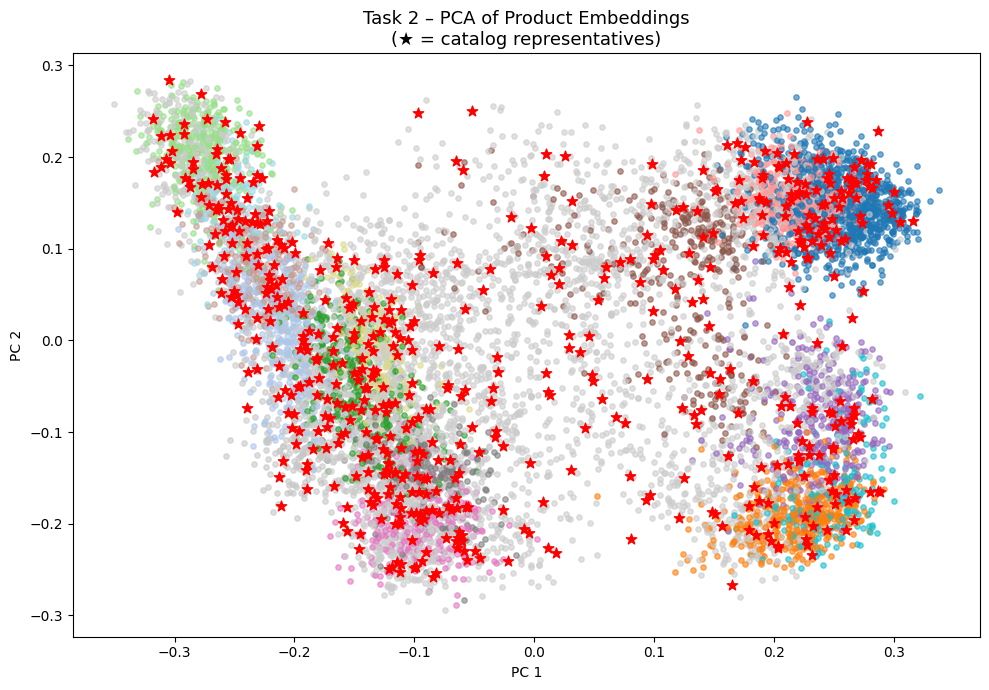

💾 Saved: task2_pca.png


In [61]:
# ─── PCA visualisation of clusters ────────────────────────────────
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(emb_normed)

# Colour by cluster (show top-15 largest clusters)
top_clusters = (pd.Series(labels)
                .value_counts()
                .head(15)
                .index.tolist())

colors_map = plt.cm.tab20(np.linspace(0, 1, len(top_clusters)))
cluster_color = {c: colors_map[i] for i, c in enumerate(top_clusters)}

fig, ax = plt.subplots(figsize=(10, 7))
for i, (x, y) in enumerate(emb_2d):
    c = labels[i]
    col = cluster_color.get(c, (0.8, 0.8, 0.8, 0.3))
    ax.scatter(x, y, color=col, alpha=0.6, s=15)

# Mark representatives
for _, rep in catalog_df.iterrows():
    idx = rep.name
    if idx < len(emb_2d):
        ax.scatter(emb_2d[idx, 0], emb_2d[idx, 1],
                   color='red', s=60, zorder=5, marker='*')

ax.set_title('Task 2 – PCA of Product Embeddings\n(★ = catalog representatives)', fontsize=13)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout()
plt.savefig('task2_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Saved: task2_pca.png")

In [62]:
# Save final catalog to CSV
catalog_df[['id','productDisplayName','articleType','masterCategory',
            'subCategory','baseColour','cluster_id','cluster_size']].to_csv(
    'unique_product_catalog.csv', index=False)
print("💾 Saved unique_product_catalog.csv")

# Summary stats
print("\n📊 Catalog Summary:")
print(catalog_df['articleType'].value_counts().head(10))

💾 Saved unique_product_catalog.csv

📊 Catalog Summary:
articleType
Tshirts                  174
Watches                   36
Perfume and Body Mist     33
Backpacks                 21
Handbags                  21
Socks                     19
Sports Shoes              19
Casual Shoes              18
Caps                      16
Tops                      12
Name: count, dtype: int64


### 📋 Task 2 Explanation

| Step | What happens |
|------|-------------|
| **1. CLIP Embeddings** | Every product image → 512-d normalised vector. |
| **2. Agglomerative Clustering** | Bottom-up hierarchical clustering with *cosine* metric. Products whose embeddings are within `distance_threshold=0.15` are considered duplicates. |
| **3. Representative Selection** | Within each cluster, the product closest to the centroid is elected as the *canonical* product. |
| **4. Unique Catalog** | One row per cluster → clean catalog free of duplicates. |

**Why Agglomerative?** Unlike k-means, it doesn't need the number of clusters upfront and handles non-spherical similarity naturally.

---
## 🔍 Task 3: Reverse Product Search (Text → Products)

**Approach:**
1. Encode the user's **text query** with CLIP's text encoder  
2. Search the **image embedding** FAISS index (same space, thanks to CLIP!)  
3. Return and visualise the top matching products

In [63]:
def text_to_product_search(query: str, top_k: int = 5) -> pd.DataFrame:
    """
    Search the product catalog using a free-text query.
    Returns top_k most relevant products.
    """
    # Encode query text with CLIP
    text_emb = get_text_embedding(query).astype(np.float32).reshape(1, -1)

    # FAISS search against image embeddings
    scores, idxs = index.search(text_emb, top_k)
    scores = scores[0]
    idxs   = idxs[0]

    results = df_valid.iloc[idxs].copy()
    results['text_similarity'] = scores
    return results[['id','productDisplayName','articleType','baseColour',
                    'text_similarity','image_path']]


# ─── Demo queries ─────────────────────────────────────────────────
queries = [
    "blue casual shirt for men",
    "red running shoes",
    "black formal trousers",
    "floral summer dress",
    "leather brown handbag",
]

for q in queries:
    results = text_to_product_search(q, top_k=5)
    print(f"\n🔎 Query: '{q}'")
    print(results[['productDisplayName','articleType','baseColour','text_similarity']].to_string(index=False))


🔎 Query: 'blue casual shirt for men'
                      productDisplayName articleType baseColour  text_similarity
United Colors of Benetton Men Blue Shirt      Shirts       Blue         0.339770
United Colors of Benetton Men Blue Shirt      Shirts       Blue         0.337220
United Colors of Benetton Men Blue Shirt      Shirts       Blue         0.336474
           Wrangler Men Tiny Green Shirt      Shirts      Green         0.333111
  French Connection Men Light Blue Shirt      Shirts       Blue         0.331507

🔎 Query: 'red running shoes'
                          productDisplayName  articleType baseColour  text_similarity
                Kalenji Kapteren Aw Red 2010 Sports Shoes        Red         0.309937
                      Kipsta F300 Sala Shoes Sports Shoes        Red         0.309937
           Puma Men Yacht L Red Casual Shoes Casual Shoes        Red         0.305670
Nike Men Dual Fusion ST 2 Black Sports Shoes Sports Shoes      Black         0.305584
                

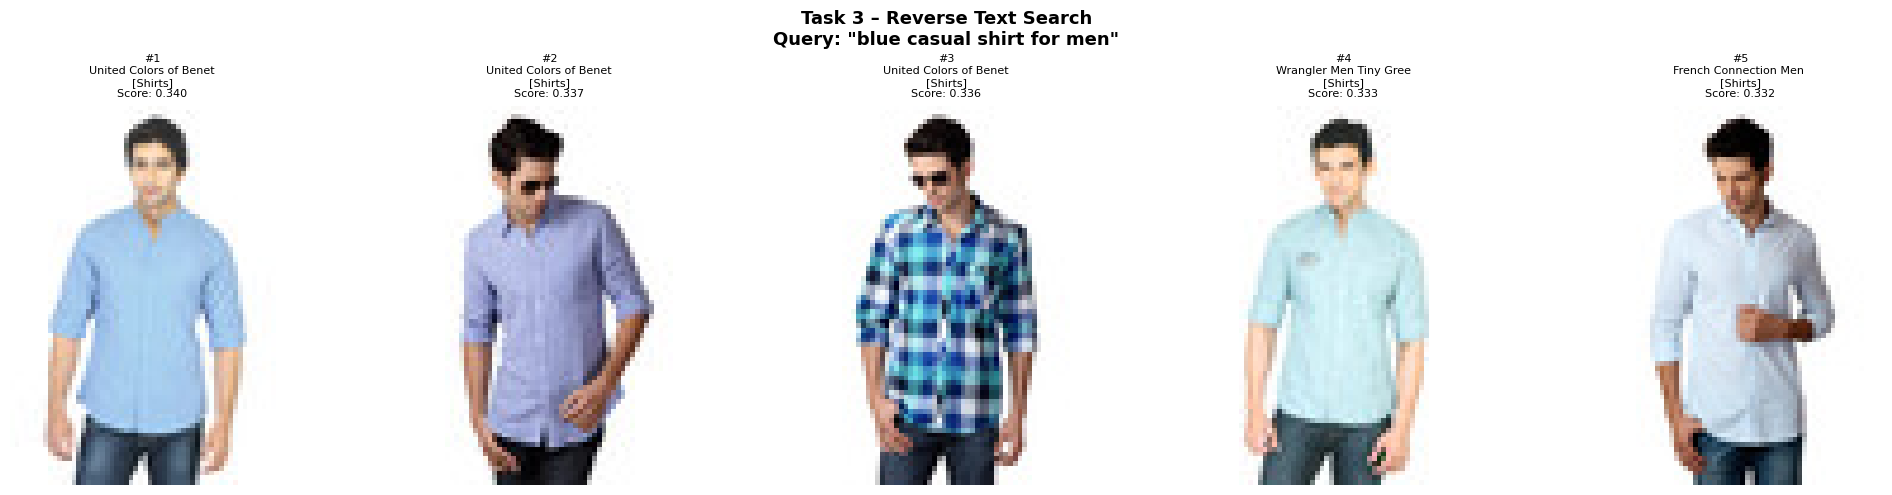

💾 Saved: task3_search_blue_casual_shirt_for_men.png


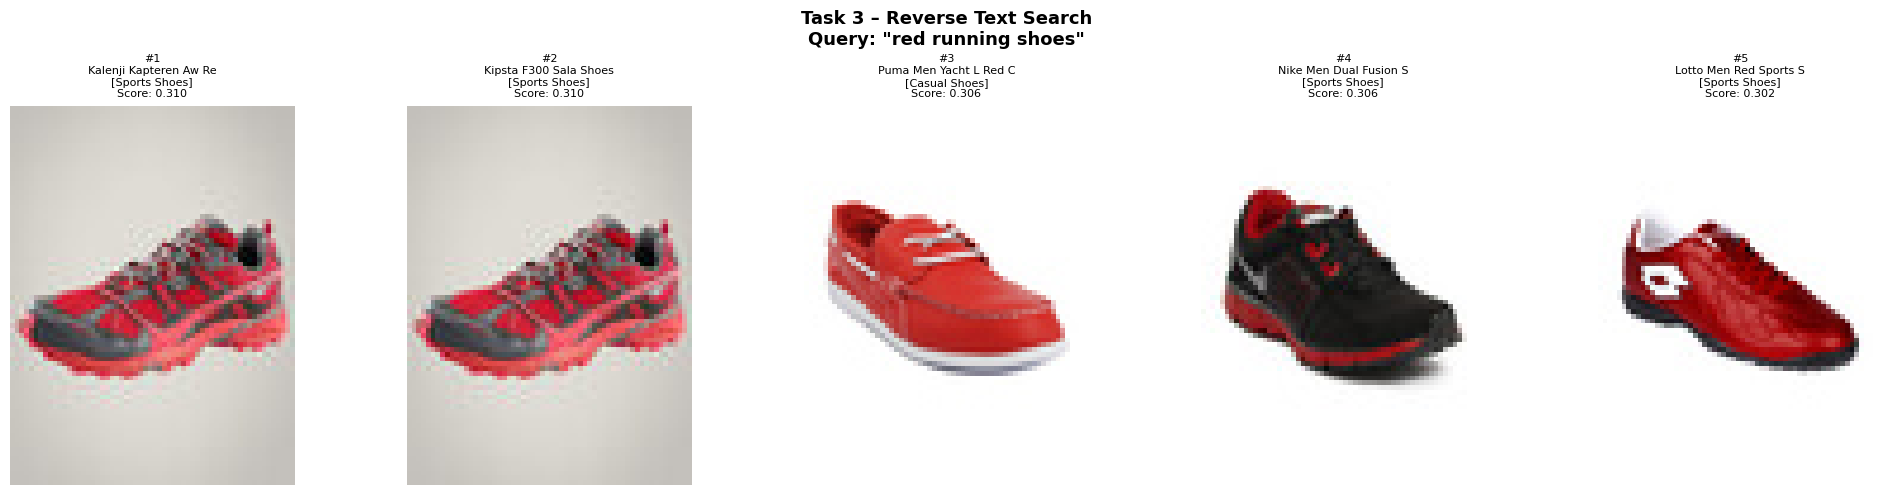

💾 Saved: task3_search_red_running_shoes.png


In [64]:
# ─── Visualisation ────────────────────────────────────────────────
def visualize_text_search(query: str, top_k: int = 5):
    results = text_to_product_search(query, top_k=top_k)

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 5))
    fig.suptitle(f'Task 3 – Reverse Text Search\nQuery: "{query}"',
                 fontsize=13, fontweight='bold')

    for rank, (ax, (_, row)) in enumerate(zip(axes, results.iterrows()), 1):
        try:
            img = Image.open(row['image_path']).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        ax.set_title(f"#{rank}\n{row['productDisplayName'][:22]}\n"
                     f"[{row['articleType']}]\nScore: {row['text_similarity']:.3f}",
                     fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    safe_q = query.replace(' ', '_')[:30]
    plt.savefig(f'task3_search_{safe_q}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: task3_search_{safe_q}.png")


# Run for two example queries
visualize_text_search("blue casual shirt for men", top_k=5)
visualize_text_search("red running shoes", top_k=5)

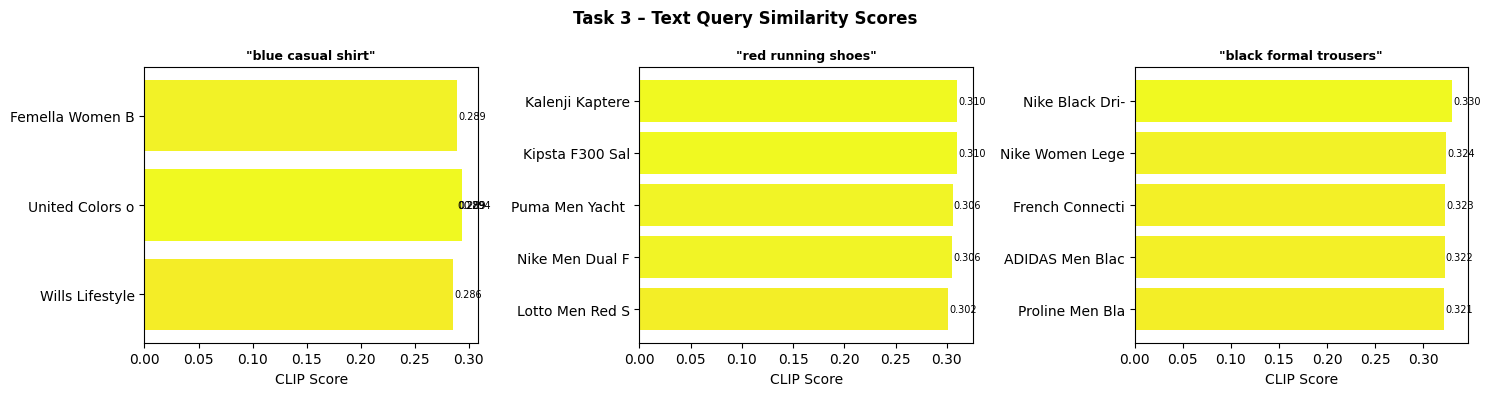

💾 Saved: task3_heatmap.png


In [65]:
# ─── Multi-query similarity heatmap ───────────────────────────────
# Shows how semantically close each query is to the top-5 retrieved products

TOP_K = 5
heatmap_queries = [
    "blue casual shirt",
    "red running shoes",
    "black formal trousers",
]

heatmap_data  = []
heatmap_labels = []

for q in heatmap_queries:
    res = text_to_product_search(q, top_k=TOP_K)
    heatmap_data.append(res['text_similarity'].values)
    heatmap_labels.append([n[:15] for n in res['productDisplayName'].tolist()])

fig, axes = plt.subplots(1, len(heatmap_queries),
                          figsize=(5 * len(heatmap_queries), 4))

for ax, q, scores, labels in zip(axes, heatmap_queries,
                                   heatmap_data, heatmap_labels):
    bars = ax.barh(labels[::-1], scores[::-1],
                   color=plt.cm.plasma(scores[::-1] / max(scores)))
    ax.set_title(f'"{q}"', fontsize=9, fontweight='bold')
    ax.set_xlabel('CLIP Score')
    for bar, s in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{s:.3f}', va='center', fontsize=7)

fig.suptitle('Task 3 – Text Query Similarity Scores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Saved: task3_heatmap.png")

### 📋 Task 3 Explanation

| Step | What happens |
|------|-------------|
| **1. CLIP Text Encoder** | The user's natural-language query is tokenised and passed through CLIP's text transformer, producing a 512-d embedding. |
| **2. Cross-modal Search** | Because CLIP aligns text and image embeddings in the same space, we search the *image* FAISS index with a *text* query – no text metadata needed! |
| **3. Rank & Display** | Products are ranked by inner-product score and shown with their image and metadata. |

**Why CLIP is perfect here:** CLIP was trained on 400M image-text pairs with a contrastive objective that maximises alignment between matching pairs. This makes `text_embedding("blue shirt") ≈ image_embedding(<blue shirt photo>)`.

---
## 📊 Overall System Summary

In [66]:
print("="*60)
print("🏁 Gen AI Bootcamp Day 2 – Final Summary")
print("="*60)
print(f"""
Dataset          : Fashion Product Images Small
Products loaded  : {len(df_valid)}
Embedding model  : openai/clip-vit-base-patch32 (512-d)
Vector index     : FAISS IndexFlatIP

Task 1 – Smart Recommendation Engine
  Method  : CLIP visual similarity + complementary category rules
  Output  : 5 complementary products per query

Task 2 – Unique Catalog Creation
  Method  : Agglomerative Clustering (cosine, threshold=0.15)
  Input   : {len(df_valid)} products
  Output  : {n_clusters} unique canonical products
  Dedup % : {(len(df_valid)-n_clusters)/len(df_valid)*100:.1f}%

Task 3 – Reverse Text Search
  Method  : CLIP text embedding → FAISS image index search
  Output  : Top-5 matching products for any free-text query
""")
print("="*60)

🏁 Gen AI Bootcamp Day 2 – Final Summary

Dataset          : Fashion Product Images Small
Products loaded  : 10000
Embedding model  : openai/clip-vit-base-patch32 (512-d)
Vector index     : FAISS IndexFlatIP

Task 1 – Smart Recommendation Engine
  Method  : CLIP visual similarity + complementary category rules
  Output  : 5 complementary products per query

Task 2 – Unique Catalog Creation
  Method  : Agglomerative Clustering (cosine, threshold=0.15)
  Input   : 10000 products
  Output  : 597 unique canonical products
  Dedup % : 94.0%

Task 3 – Reverse Text Search
  Method  : CLIP text embedding → FAISS image index search
  Output  : Top-5 matching products for any free-text query



---
## 🎓 Key Concepts Learned

| Concept | Used in |
|---------|--------|
| **CLIP Embeddings** | All 3 tasks |
| **FAISS Vector Search** | Task 1 & 3 |
| **Cosine Similarity** | All 3 tasks |
| **Agglomerative Clustering** | Task 2 |
| **Cross-modal Retrieval** | Task 3 |
| **PCA Visualisation** | Task 2 |
| **Complementary Rules** | Task 1 |